# Multi-Class Prediction of Obesity Risk


## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from warnings import filterwarnings
filterwarnings('ignore')

color_list = ["#A5D7E8", "#576CBC", "#19376D", "#0B2447"]
cmap_custom = ListedColormap(color_list)

RANDOM_STATE = 0

## Loading the data

In [2]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s4e2/train.csv").set_index("id")
test  = pd.read_csv("/kaggle/input/competitions/playground-series-s4e2/test.csv").set_index("id")

print("train:", train.shape)
print("test:", test.shape)

train: (20758, 17)
test: (13840, 16)


In [3]:
train.head().T

id,0,1,2,3,4
Gender,Male,Female,Female,Female,Male
Age,24.443011,18.0,18.0,20.952737,31.641081
Height,1.699998,1.56,1.71146,1.71073,1.914186
Weight,81.66995,57.0,50.165754,131.274851,93.798055
family_history_with_overweight,yes,yes,yes,yes,yes
FAVC,yes,yes,yes,yes,yes
FCVC,2.0,2.0,1.880534,3.0,2.679664
NCP,2.983297,3.0,1.411685,3.0,1.971472
CAEC,Sometimes,Frequently,Sometimes,Sometimes,Sometimes
SMOKE,no,no,no,no,no


**Feature glossary**

* `Gender`, `Age`, `Height`, `Weight` — physical attributes
* `family_history_with_overweight` — family history of obesity
* `FAVC` — frequent high-caloric food consumption
* `FCVC` — frequency of vegetable consumption
* `NCP` — number of main meals
* `CAEC` — eating between meals
* `SMOKE` — tobacco use
* `CH2O` — daily water consumption
* `SCC` — calorie-consumption monitoring
* `FAF` — physical-activity frequency
* `TUE` — time using technology devices
* `CALC` — alcohol consumption
* `MTRANS` — transportation used
* `NObeyesdad` — **target**: obesity level

In [4]:
target = train["NObeyesdad"]
train  = train.drop("NObeyesdad", axis="columns")

## Exploratory Data Analysis

In [5]:
target.value_counts(normalize=True).round(3)

NObeyesdad
Obesity_Type_III       0.195
Obesity_Type_II        0.156
Normal_Weight          0.148
Obesity_Type_I         0.140
Insufficient_Weight    0.122
Overweight_Level_II    0.121
Overweight_Level_I     0.117
Name: proportion, dtype: float64

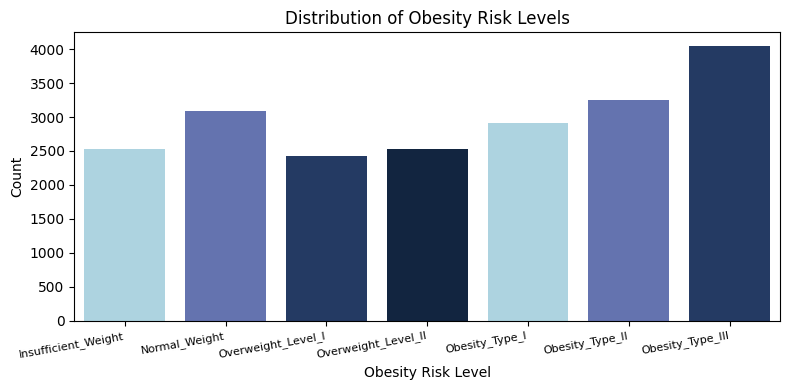

In [6]:
sorted_labels = ['Insufficient_Weight', 'Normal_Weight',
                 'Overweight_Level_I', 'Overweight_Level_II',
                 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']

plt.figure(figsize=(8, 4))
ax = sns.countplot(x=target, order=sorted_labels, palette=color_list)
plt.title('Distribution of Obesity Risk Levels')
plt.xlabel('Obesity Risk Level'); plt.ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=10, ha='right', fontsize=8)
plt.tight_layout(); plt.show()

The target is multiclass with 7 ordered levels. Classes are not perfectly balanced (the largest class is roughly double the smallest).

In [7]:
target_cat = pd.Categorical(target, categories=sorted_labels, ordered=True)
target_numeric = pd.Series(target_cat.codes, index=target.index, name="target")

# Quick check of the mapping
dict(enumerate(sorted_labels))

{0: 'Insufficient_Weight',
 1: 'Normal_Weight',
 2: 'Overweight_Level_I',
 3: 'Overweight_Level_II',
 4: 'Obesity_Type_I',
 5: 'Obesity_Type_II',
 6: 'Obesity_Type_III'}

In [8]:
target_numeric.head()

id
0    3
1    1
2    0
3    6
4    3
Name: target, dtype: int8

In [9]:
print("Missing values in train:", int(train.isnull().sum().sum()))
print("Missing values in test :", int(test.isnull().sum().sum()))

Missing values in train: 0
Missing values in test : 0


In [10]:
categorical_features = train.columns[train.dtypes == "object"].tolist()
numeric_features     = train.columns[train.dtypes != "object"].tolist()
print("Categorical:", categorical_features)
print("Numeric    :", numeric_features)

Categorical: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']
Numeric    : ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']


In [11]:
train[categorical_features].nunique()

Gender                            2
family_history_with_overweight    2
FAVC                              2
CAEC                              4
SMOKE                             2
SCC                               2
CALC                              3
MTRANS                            5
dtype: int64

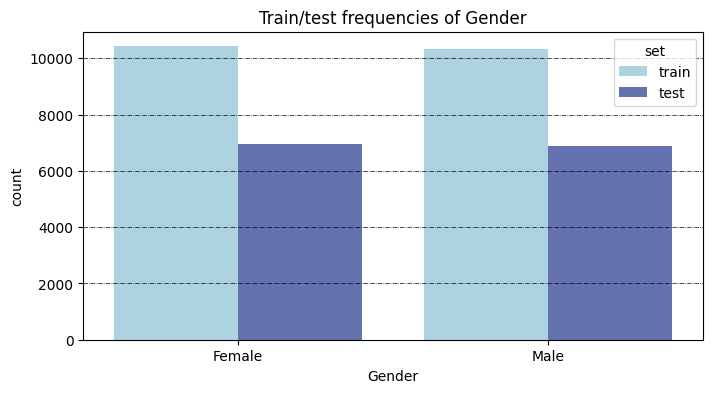

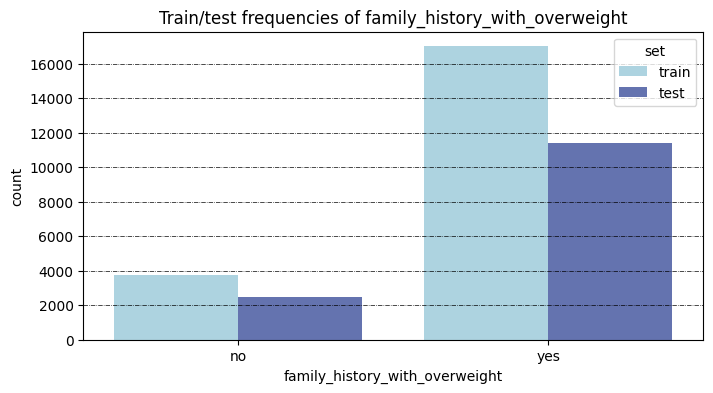

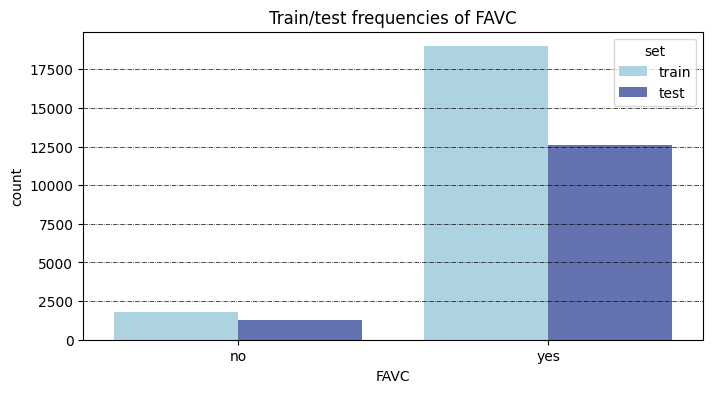

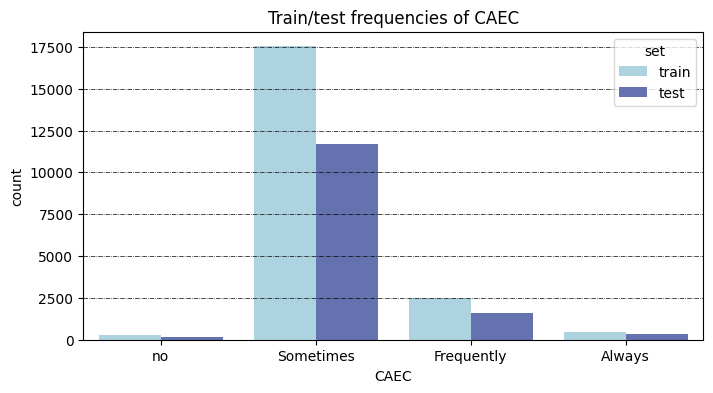

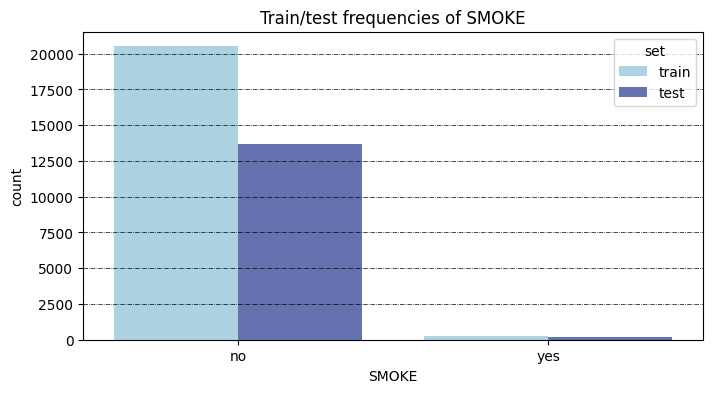

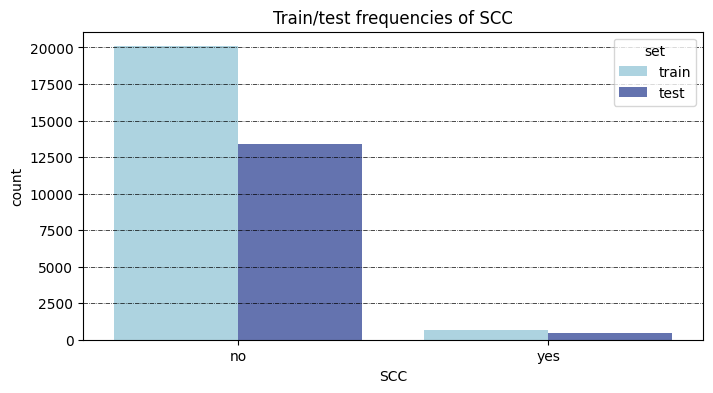

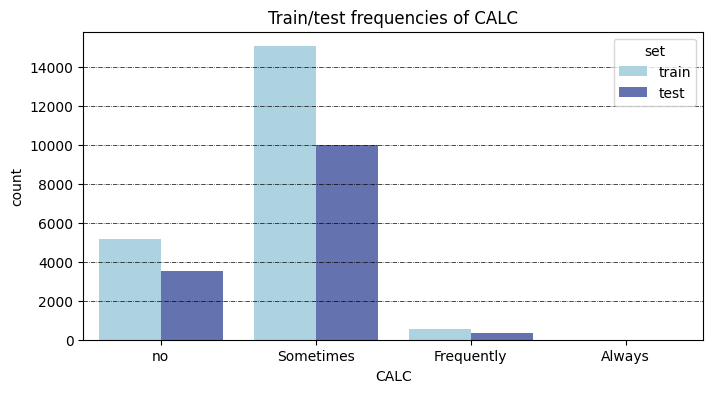

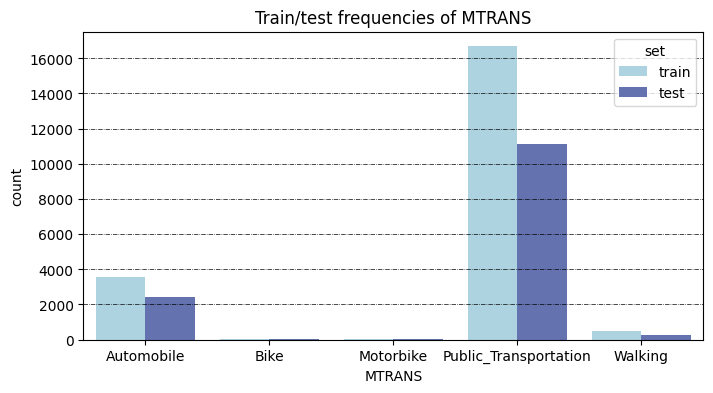

In [12]:
def plot_count_pairs(train, test, feature, order=None):
    data_df = train.copy(); data_df['set'] = 'train'
    data_df = pd.concat([data_df, test.copy()]).fillna('test')
    f, ax = plt.subplots(1, 1, figsize=(8, 4))
    sns.countplot(x=feature, data=data_df, hue='set', palette=color_list, order=order)
    plt.grid(color="black", linestyle="-.", linewidth=0.5, axis="y")
    ax.set_title(f"Train/test frequencies of {feature}"); plt.show()

for feature in categorical_features:
    if feature in ["CAEC", "CALC"]:
        order = ["no", "Sometimes", "Frequently", "Always"]
    else:
        order = sorted(train[feature].unique())
    plot_count_pairs(train, test, feature, order=order)

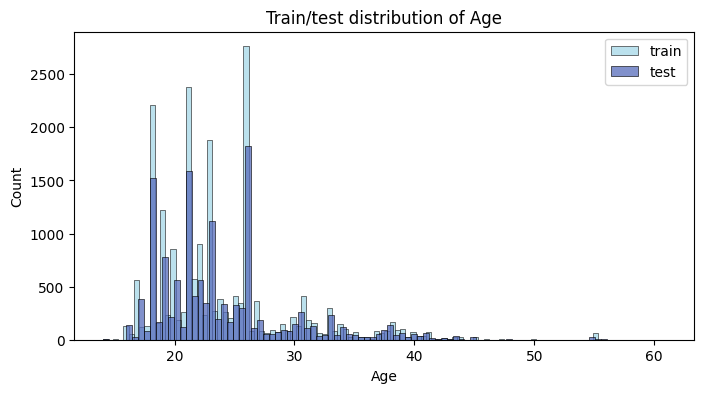

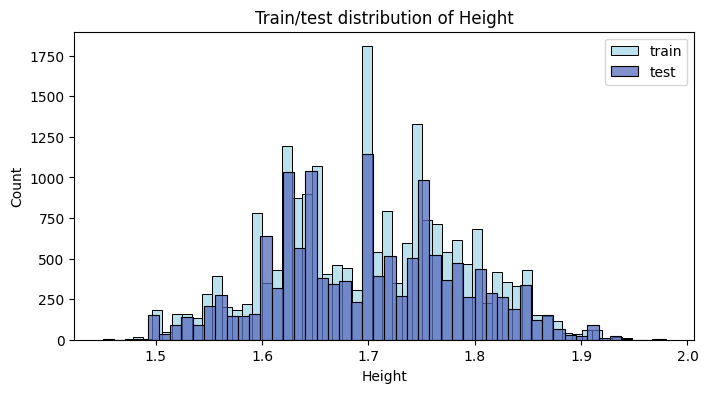

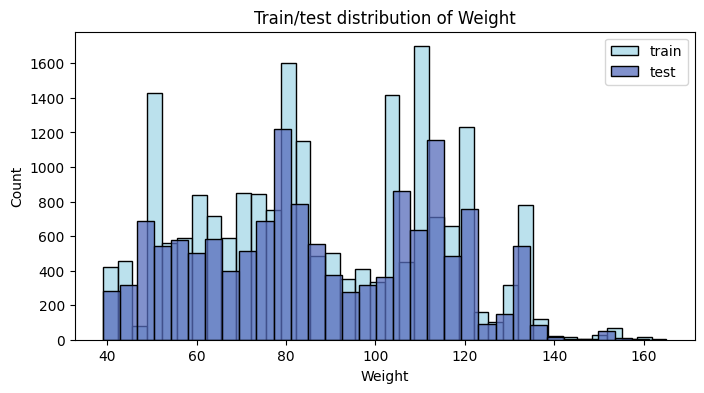

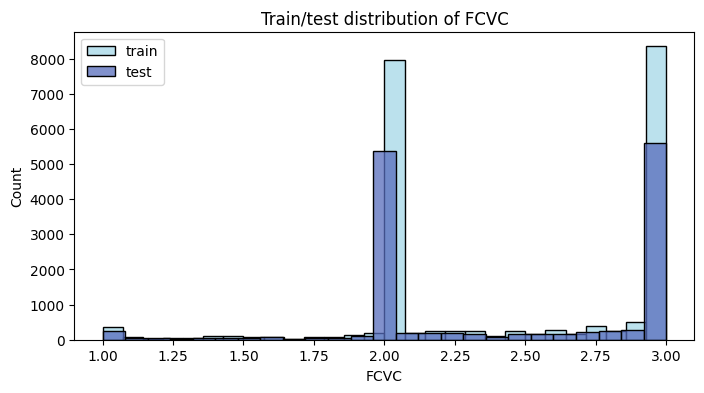

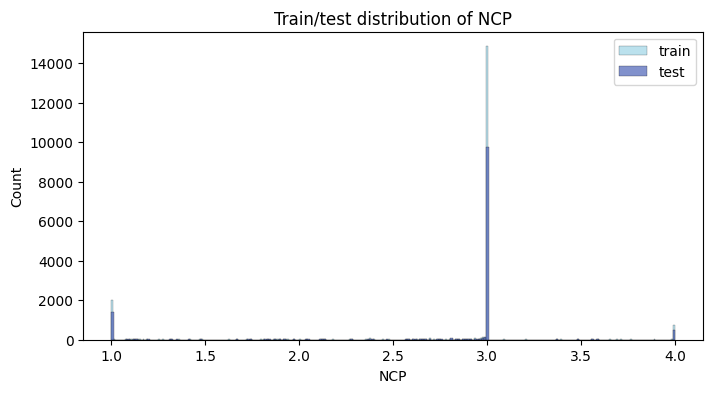

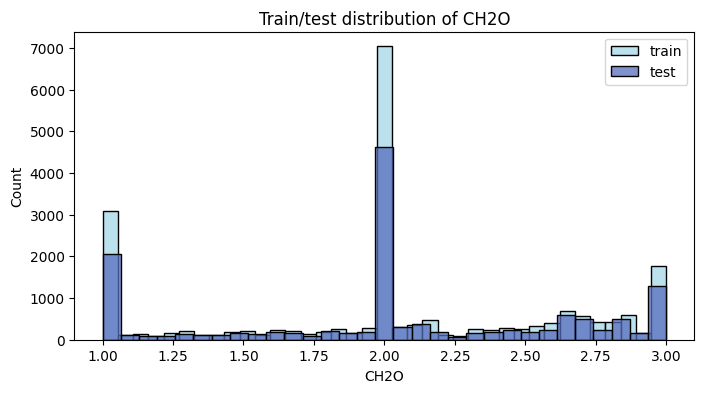

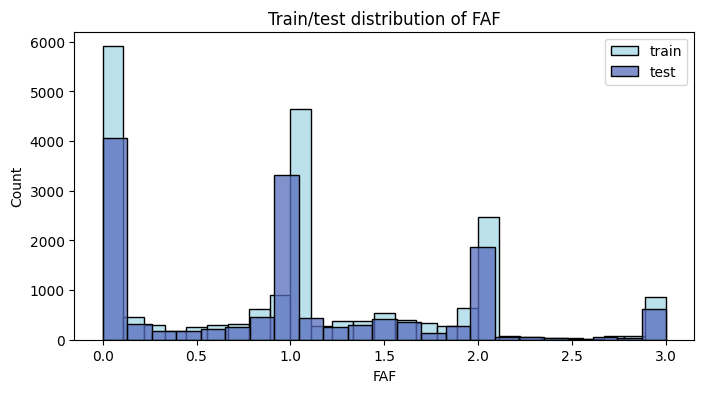

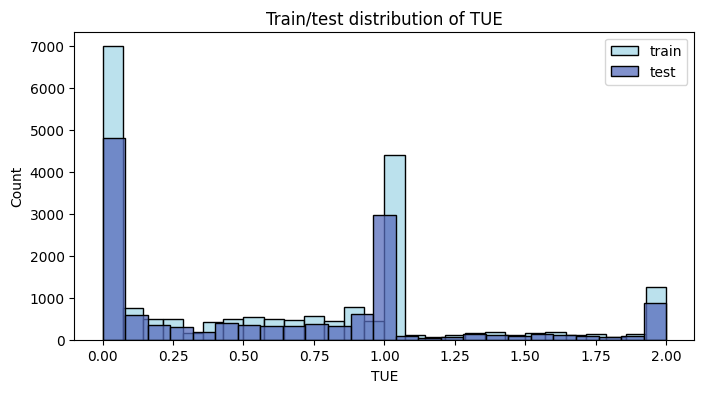

In [13]:
def plot_distribution_pairs(train, test, feature):
    data_df = train.copy(); data_df['set'] = 'train'
    data_df = pd.concat([data_df, test.copy()]).fillna('test')
    data_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    f, ax = plt.subplots(1, 1, figsize=(8, 4))
    for i, s in enumerate(data_df['set'].unique()):
        sns.histplot(data_df.loc[data_df['set'] == s, feature],
                     color=color_list[i], ax=ax, label=s)
    ax.set_title(f"Train/test distribution of {feature}"); ax.legend(); plt.show()

for feature in numeric_features:
    plot_distribution_pairs(train, test, feature)

## Encoding categorical features

We fit a `OneHotEncoder` on the train & test categories.

In [14]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
encoder.fit(pd.concat([train[categorical_features], test[categorical_features]], axis=0))

train_encoded_df = pd.DataFrame(
    encoder.transform(train[categorical_features]),
    columns=encoder.get_feature_names_out(categorical_features),
    index=train.index)

test_encoded_df = pd.DataFrame(
    encoder.transform(test[categorical_features]),
    columns=encoder.get_feature_names_out(categorical_features),
    index=test.index)

In [15]:
# Sanity check: column sums per set
pd.concat([train_encoded_df.sum().astype(int),
           test_encoded_df.sum().astype(int)],
          axis=1, keys=['Train', 'Test'])

,Train,Test
Gender_Female,10422,6965
Gender_Male,10336,6875
family_history_with_overweight_no,3744,2456
family_history_with_overweight_yes,17014,11384
FAVC_no,1776,1257
FAVC_yes,18982,12583
CAEC_Always,478,359
CAEC_Frequently,2472,1617
CAEC_Sometimes,17529,11689
CAEC_no,279,175


`CALC_Always` has (almost) no support in training. We merge it with `CALC_Frequently` into a single `CALC_Always|Frequently` column so the encoding is stable across train and test.

In [16]:
combine_columns = ['CALC_Always', 'CALC_Frequently']
for df in (train_encoded_df, test_encoded_df):
    df['CALC_Always|Frequently'] = df[combine_columns].sum(axis=1)
train_encoded_df = train_encoded_df.drop(columns=combine_columns)
test_encoded_df  = test_encoded_df.drop(columns=combine_columns)

We also add **ordinal** encodings of `CALC` and `CAEC`, since 'no < Sometimes < Frequently < Always' carries an order that one-hot throws away.

In [17]:
levels = {"Always": 3, "Frequently": 2, "Sometimes": 1, "no": 0}
for df in (train, test):
    df["CALC_ord"] = df["CALC"].map(levels)
    df["CAEC_ord"] = df["CAEC"].map(levels)

In [18]:
train = pd.concat([train.drop(categorical_features, axis=1), train_encoded_df], axis=1)
test  = pd.concat([test.drop(categorical_features, axis=1),  test_encoded_df],  axis=1)
print("Encoded train shape:", train.shape)

Encoded train shape: (20758, 32)


## Feature engineering

A small set of domain-motivated features. **BMI** is the strongest signal here (the target categories are BMI-based), and we keep it. The others capture lifestyle balance.

In [19]:
# BMI: the classic obesity indicator
train['BMI'] = train['Weight'] / (train['Height'] ** 2)
test['BMI']  = test['Weight']  / (test['Height']  ** 2)

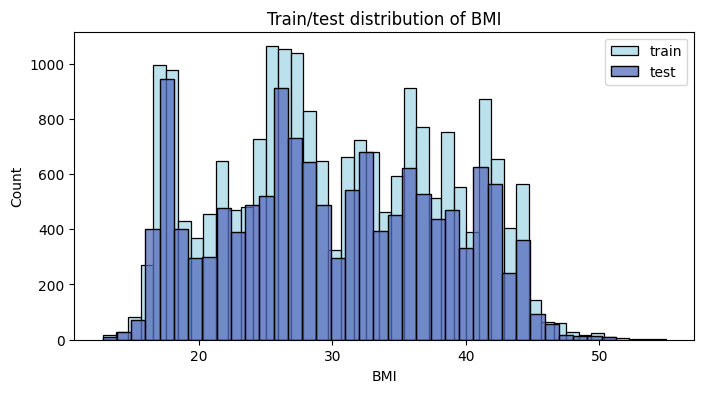

In [20]:
plot_distribution_pairs(train, test, feature="BMI")

In [21]:
# Net physical activity: exercise minus screen time
train['Physical_Activity_Level'] = train['FAF'] - train['TUE']
test['Physical_Activity_Level']  = test['FAF']  - test['TUE']

In [22]:
# Meal habits: vegetable frequency x number of meals
train['Meal_Habits'] = train['FCVC'] * train['NCP']
test['Meal_Habits']  = test['FCVC']  * test['NCP']

In [23]:
# Healthy nutrition: vegetables relative to high-calorie food habit
train['Healthy_Nutrition_Habits'] = train['FCVC'] / (2 * train['FAVC_no'] - 1)
test['Healthy_Nutrition_Habits']  = test['FCVC']  / (2 * test['FAVC_no']  - 1)

In [24]:
# Technology usage relative to age
train['Tech_Usage_Score'] = train['TUE'] / train['Age']
test['Tech_Usage_Score']  = test['TUE']  / test['Age']

##  Cross-validation 

Since the data is not perfectly balanced, we have to use `StratifiedKFold` and use it for **every** model so the comparison is fair.

In [25]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## Model Comparison

We compare five models from different families on the **same feature matrix**:

* **Logistic Regression** — linear, interpretable baseline (scaled inside a pipeline)
* **Random Forest** — bagged trees
* **XGBoost** — gradient-boosted trees (GPU)
* **CatBoost** — gradient boosting with ordered boosting (GPU)
* **LightGBM** — fast histogram-based boosting


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

n_classes = target_numeric.nunique()

models = {
    "LogisticRegression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),

    "RandomForest": RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),

    "XGBoost": XGBClassifier(
        booster='gbtree', device='cuda', tree_method='hist',
        objective='multi:softmax', num_class=n_classes,
        n_estimators=300, max_depth=6, verbosity=0,
        random_state=RANDOM_STATE),

    "CatBoost": CatBoostClassifier(
        task_type='GPU', iterations=500, depth=6,
        learning_rate=0.05, loss_function='MultiClass',
        random_seed=RANDOM_STATE, verbose=0),

    "LightGBM": LGBMClassifier(
        boosting_type='gbdt', objective='multiclass',
        num_class=n_classes, n_estimators=500, learning_rate=0.05,
        max_depth=9, colsample_bytree=0.4, subsample=0.85,
        random_state=RANDOM_STATE, verbosity=-1),
}

We score each model with stratified-CV accuracy and store out-of-fold predictions for error analysis.

In [27]:
from sklearn.base import clone
from sklearn.metrics import accuracy_score

results = {}
oof_preds = {}

for name, model in models.items():
    oof = np.zeros(len(target_numeric), dtype=int)
    fold_scores = []

    for train_idx, val_idx in cv.split(train, target_numeric):
        X_tr, X_val = train.iloc[train_idx], train.iloc[val_idx]
        y_tr, y_val = target_numeric.iloc[train_idx], target_numeric.iloc[val_idx]

        m = clone(model)
        m.fit(X_tr, y_tr)
        preds = m.predict(X_val).ravel()   # flatten (n,1) -> (n,)

        oof[val_idx] = preds
        fold_scores.append(accuracy_score(y_val, preds))

    results[name] = sum(fold_scores) / len(fold_scores)
    oof_preds[name] = oof
    print(f"{name}: accuracy = {results[name]:.4f}")

LogisticRegression: accuracy = 0.8669
RandomForest: accuracy = 0.8997
XGBoost: accuracy = 0.9024
CatBoost: accuracy = 0.9024
LightGBM: accuracy = 0.9063


### Comparison summary

In [28]:
summary = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": list(results.values()),
}).sort_values("Accuracy", ascending=False).reset_index(drop=True)

summary

,Model,Accuracy
0,LightGBM,0.906350
1,XGBoost,0.902399
2,CatBoost,0.902351
3,RandomForest,0.899701
4,LogisticRegression,0.866895


In [29]:
from sklearn.metrics import classification_report, confusion_matrix

best_name = summary.iloc[0]["Model"]
print("Best model:", best_name)
print()
print(classification_report(target_numeric, oof_preds[best_name],
                            target_names=sorted_labels))

Best model: LightGBM

                     precision    recall  f1-score   support

Insufficient_Weight       0.93      0.93      0.93      2523
      Normal_Weight       0.87      0.89      0.88      3082
 Overweight_Level_I       0.81      0.77      0.79      2427
Overweight_Level_II       0.81      0.82      0.81      2522
     Obesity_Type_I       0.89      0.89      0.89      2910
    Obesity_Type_II       0.97      0.97      0.97      3248
   Obesity_Type_III       1.00      1.00      1.00      4046

           accuracy                           0.91     20758
          macro avg       0.90      0.90      0.90     20758
       weighted avg       0.91      0.91      0.91     20758



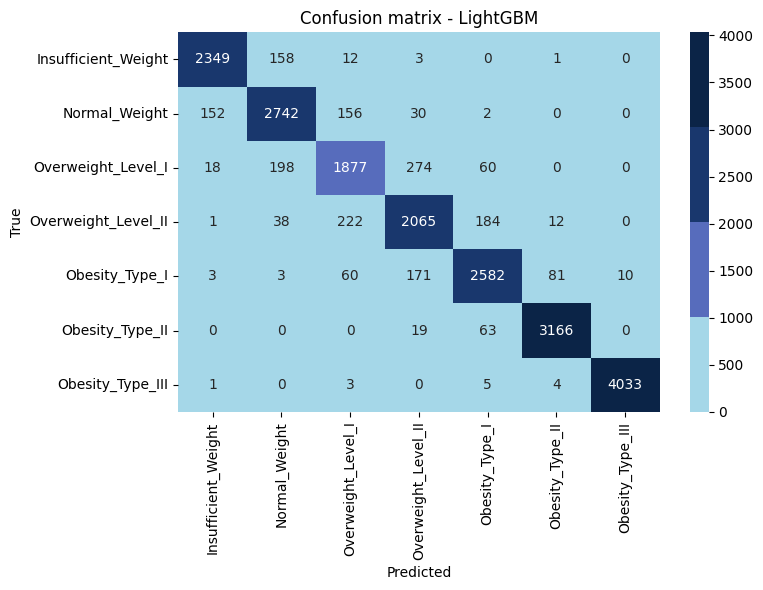

In [30]:
conf = confusion_matrix(target_numeric, oof_preds[best_name])

plt.figure(figsize=(8, 6))
sns.heatmap(conf, annot=True, fmt="d", cmap=cmap_custom,
            xticklabels=sorted_labels, yticklabels=sorted_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion matrix - {best_name}")
plt.tight_layout()
plt.show()

As expected, most confusion sits between **adjacent** classes (e.g. Overweight_Level_I vs II), whose boundaries are inherently fuzzy. This is reassuring: the model rarely makes far-off errors.